# Cardiovascular Disease (CVD) Risk Screening

This notebook builds an end-to-end pipeline for predicting **cardiovascular disease risk** from routine health checkup data.

**Workflow:**
1. Load and explore the raw dataset
2. Clean the data and remove invalid/outlier records
3. Engineer a BMI feature and prepare train/test splits
4. Train a PyTorch neural network (MLP) using two optimizers (Adam vs SGD)
5. Evaluate and compare model performance
6. Explain predictions using SHAP
7. Run risk predictions for example patients

## 1. Import Libraries

We import all the libraries needed for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), deep learning (`torch`), preprocessing/metrics (`scikit-learn`), model explainability (`shap`), model persistence (`joblib`), and performance/resource tracking (`time`, `psutil`, `tracemalloc`).

In [3]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch for building and training the neural network
import torch
import torch.nn as nn

# Scikit-learn utilities for splitting data and scaling features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn metrics for evaluating classification performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# SHAP for model explainability (feature contribution analysis)
import shap

# joblib to save/load the fitted scaler
import joblib

# Standard libraries for timing and resource (memory/CPU) monitoring
import os
import time
import psutil
import tracemalloc

print("All libraries imported successfully...")


All libraries imported successfully...


## 2. Load the Dataset

The dataset is the **Cardiovascular Disease** dataset (`cardio_train.csv`), which uses `;` as the column separator.

In [4]:
# Load the CSV file from local workspace or Kaggle dataset path
import os
import pandas as pd

if os.path.exists('raw_data.csv'):
    df = pd.read_csv('raw_data.csv', sep=';')
elif os.path.exists('preprocessed_data.csv'):
    df = pd.read_csv('preprocessed_data.csv')
elif os.path.exists('/kaggle/input/datasets/prinsipethani/dsetofcvd/cardio_train.csv'):
    df = pd.read_csv('/kaggle/input/datasets/prinsipethani/dsetofcvd/cardio_train.csv', sep=';')
else:
    df = pd.read_csv('cardio_train.csv', sep=';')


## 3. Initial Data Exploration

Before cleaning, let's quickly check the shape, column names, and a preview of the raw data.

In [5]:
# Check how many rows and columns the dataset has
print(f"Dataset Shape : {df.shape}")


Dataset Shape : (70000, 13)


In [6]:
# List all column names in the dataset
print("\nColumn Names:")
print(df.columns.tolist())



Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [7]:
# Preview the first five rows to understand the data format
print("\n First five rows of data:")
display(df.head())



 First five rows of data:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 4. Data Cleaning & Feature Engineering

We now clean the dataset in a few steps:
- Drop the `id` column (not useful for prediction)
- Convert `age` from days to years (rounded to 1 decimal)
- Remove physiologically impossible blood pressure readings
- Remove extreme height/weight outliers (top/bottom 1%)
- Engineer a new `BMI` feature from height and weight

In [8]:
# Work on a copy so the original dataframe stays untouched
df_clean = df.copy()

# The 'id' column is just a row identifier, so it carries no predictive value
df_clean.drop(columns=["id"], inplace=True)

# Convert age from days to years and round to 1 decimal place for readability
df_clean["age"] = (df_clean["age"] / 365).round(1)

display(df_clean.head())


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.4,2,168,62.0,110,80,1,1,0,0,1,0
1,55.4,1,156,85.0,140,90,3,1,0,0,1,1
2,51.7,1,165,64.0,130,70,3,1,0,0,0,1
3,48.3,2,169,82.0,150,100,1,1,0,0,1,1
4,47.9,1,156,56.0,100,60,1,1,0,0,0,0


In [9]:
# Remove rows with unrealistic systolic blood pressure (ap_hi) values
df_clean = df_clean[(df_clean["ap_hi"] > 60) & (df_clean["ap_hi"] < 250)]

# Remove rows with unrealistic diastolic blood pressure (ap_lo) values
df_clean = df_clean[(df_clean["ap_lo"] > 40) & (df_clean["ap_lo"] < 200)]

# Systolic pressure should always be greater than or equal to diastolic pressure
df_clean = df_clean[df_clean["ap_hi"] >= df_clean["ap_lo"]]


In [10]:
# Remove extreme outliers (bottom 1% and top 1%) in height and weight
for col in ["height", "weight"]:
    q1, q2 = df_clean[col].quantile([0.01, 0.99])
    df_clean = df_clean[(df_clean[col] >= q1) & (df_clean[col] <= q2)]

# Engineer a new feature: Body Mass Index (BMI = weight(kg) / height(m)^2)
df_clean["BMI"] = df_clean["weight"] / ((df_clean["height"] / 100) ** 2)

# Reset the index after all the row filtering above
df_clean.reset_index(drop=True, inplace=True)

display(df_clean.head())


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50.4,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55.4,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51.7,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48.3,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47.9,1,156,56.0,100,60,1,1,0,0,0,0,23.011177


## 5. Split Features and Target

`cardio` is the target variable (1 = has cardiovascular disease, 0 = does not). All other columns are used as input features.

In [11]:
# Separate the input features (X) from the target label (y)
X = df_clean.drop("cardio", axis=1)
y = df_clean["cardio"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

display(X.head())
display(y.head())


Feature Matrix Shape : (66203, 12)
Target Shape : (66203,)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,50.4,2,168,62.0,110,80,1,1,0,0,1,21.967120
1,55.4,1,156,85.0,140,90,3,1,0,0,1,34.927679
2,51.7,1,165,64.0,130,70,3,1,0,0,0,23.507805
3,48.3,2,169,82.0,150,100,1,1,0,0,1,28.710479
4,47.9,1,156,56.0,100,60,1,1,0,0,0,23.011177


0    0
1    1
2    1
3    1
4    0
Name: cardio, dtype: int64

## 6. Train-Test Split

We hold out 20% of the data for testing. `stratify=y` keeps the class balance (disease vs. no disease) consistent between the train and test sets.

In [12]:
# Split into training (80%) and test (20%) sets, preserving class balance via stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train Shape : {X_train.shape}")
print(f"Test Shape  : {X_test.shape}")


Train Shape : (52962, 12)
Test Shape  : (13241, 12)


## 7. Feature Scaling

Neural networks train more effectively when input features are on a similar scale, so we standardize the features to zero mean and unit variance using `StandardScaler`. Note that the scaler is **fit only on the training data** and then applied to the test data, to avoid data leakage.

In [13]:
# Fit the scaler on training data only, then transform both train and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Test Shape :", X_test_scaled.shape)


Scaled Training Shape : (52962, 12)
Scaled Test Shape : (13241, 12)


## 8. Convert Data to PyTorch Tensors

PyTorch models operate on tensors rather than NumPy arrays or pandas objects, so we convert the scaled features and labels into `float32` tensors.

In [14]:
# Convert scaled training features/labels to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

# Convert scaled test features/labels to PyTorch tensors
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)

print("X_train_t :", X_train_t.shape)
print("X_test_t :", X_test_t.shape)


X_train_t : torch.Size([52962, 12])
X_test_t : torch.Size([13241, 12])


## 9. Define the Neural Network Model

We build a simple feed-forward **Multi-Layer Perceptron (MLP)** for binary classification. Each hidden layer uses a Linear transform, followed by Batch Normalization, ReLU activation, and Dropout for regularization. The final layer outputs a single raw logit (no sigmoid applied here, since we use `BCEWithLogitsLoss` during training).

In [15]:
class CVDRiskMLP(nn.Module):

    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Dynamically build hidden layers based on the hidden_dims tuple
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))      # linear transform
            layers.append(nn.BatchNorm1d(h))            # normalize activations for stable training
            layers.append(nn.ReLU())                    # non-linearity
            layers.append(nn.Dropout(dropout))           # regularization to reduce overfitting
            prev_dim = h

        # Output layer: single logit for binary classification
        layers.append(nn.Linear(prev_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Squeeze the last dimension so output shape matches the target shape (batch_size,)
        return self.net(x).squeeze(-1)

# Print the model architecture as a sanity check
print(CVDRiskMLP(input_dim=X_train_t.shape[1]))


CVDRiskMLP(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 10. Define the Training Function

This function trains the MLP for a given number of epochs using mini-batch gradient descent, with a choice of optimizer (`adam` or `sgd`). It tracks both training loss and validation (test set) loss at every epoch, and returns the trained model along with the loss history.

In [16]:
def train_model(optimizer_name, epochs=50, lr=1e-3, batch_size=256, seed=42):
    # Fix the random seed for reproducible results
    torch.manual_seed(seed)

    model = CVDRiskMLP(input_dim=X_train_t.shape[1])
    criterion = nn.BCEWithLogitsLoss()  # combines sigmoid + binary cross-entropy loss

    # Choose the optimizer based on the given name
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    n = X_train_t.shape[0]
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)  # shuffle training data each epoch
        epoch_loss = 0.0

        # Mini-batch training loop
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]

            optimizer.zero_grad()          # reset gradients
            logits = model(xb)             # forward pass
            loss = criterion(logits, yb)   # compute loss
            loss.backward()                # backpropagation
            optimizer.step()               # update weights

            epoch_loss += loss.item() * len(idx)

        # Average training loss for this epoch
        train_losses.append(epoch_loss / n)

        # Evaluate on the validation/test set (no gradient tracking needed)
        model.eval()
        with torch.no_grad():
            val_logits = model(X_test_t)
            val_loss = criterion(val_logits, y_test_t).item()
        val_losses.append(val_loss)

    return model, train_losses, val_losses

print("Training function ready.")


Training function ready.


## 11. Train the Model with the Adam Optimizer

Adam is an adaptive learning-rate optimizer that generally converges faster and more reliably than plain SGD.

In [17]:
# Train the MLP using the Adam optimizer, and measure how long training takes
start_time = time.time()

adam_model, adam_train_losses, adam_val_losses = train_model("adam")

adam_training_time = time.time() - start_time

print("=" * 70)
print("ADAM MODEL TRAINED")
print("=" * 70)
print(f"Training Time     : {adam_training_time:.2f} seconds")
print(f"Final Train Loss  : {adam_train_losses[-1]:.4f}")
print(f"Final Val Loss     : {adam_val_losses[-1]:.4f}")


ADAM MODEL TRAINED
Training Time     : 43.72 seconds
Final Train Loss  : 0.5496
Final Val Loss     : 0.5463


## 12. Train the Model with the SGD Optimizer

We also train an identical model using classic Stochastic Gradient Descent (with momentum) so we can compare it against Adam later.

In [18]:
# Train the same MLP architecture using SGD (with momentum) for comparison against Adam
start_time = time.time()

sgd_model, sgd_train_losses, sgd_val_losses = train_model("sgd")

sgd_training_time = time.time() - start_time

print("=" * 70)
print("SGD MODEL TRAINED")
print("=" * 70)
print(f"Training Time     : {sgd_training_time:.2f} seconds")
print(f"Final Train Loss  : {sgd_train_losses[-1]:.4f}")
print(f"Final Val Loss     : {sgd_val_losses[-1]:.4f}")


SGD MODEL TRAINED
Training Time     : 31.01 seconds
Final Train Loss  : 0.5624
Final Val Loss     : 0.5514


## 13. Plot Training & Validation Loss Curves

Plotting the loss curves side-by-side lets us visually compare how quickly and smoothly each optimizer converges, and check for signs of overfitting (e.g. validation loss increasing while training loss keeps dropping).

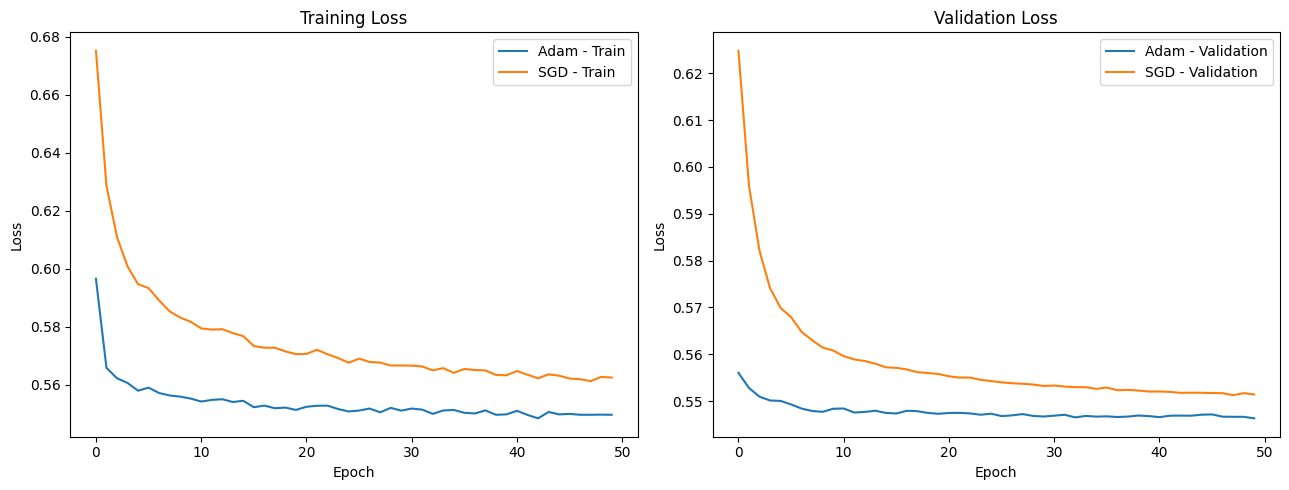

In [19]:
# Create a side-by-side comparison of training and validation loss curves for both optimizers
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Left subplot: training loss comparison
ax[0].plot(adam_train_losses, label="Adam - Train")
ax[0].plot(sgd_train_losses, label="SGD - Train")
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Right subplot: validation loss comparison
ax[1].plot(adam_val_losses, label="Adam - Validation")
ax[1].plot(sgd_val_losses, label="SGD - Validation")
ax[1].set_title("Validation Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.tight_layout()
plt.show()


## 14. Evaluate & Compare Model Performance

We evaluate both trained models on the held-out test set using standard classification metrics: Accuracy, Precision, Recall, F1 Score, and ROC AUC.

In [20]:
def evaluate_model(model, threshold=0.5):
    model.eval()
    with torch.no_grad():
        # Apply sigmoid to convert raw logits into probabilities
        probs = torch.sigmoid(model(X_test_t)).numpy()
    # Convert probabilities into binary class predictions using the given threshold
    preds = (probs >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs)
    }, probs, preds


# Evaluate both the Adam-trained and SGD-trained models on the test set
adam_metrics, adam_probs, adam_preds = evaluate_model(adam_model)
sgd_metrics, sgd_probs, sgd_preds = evaluate_model(sgd_model)

# Combine both sets of metrics into a single comparison table
comparison_df = pd.DataFrame({
    "Metric": list(adam_metrics.keys()),
    "Adam": list(adam_metrics.values()),
    "SGD": list(sgd_metrics.values())
})

print("=" * 70)
print("MODEL COMPARISON - ADAM vs SGD")
print("=" * 70)
display(comparison_df)


MODEL COMPARISON - ADAM vs SGD


,Metric,Adam,SGD
0,Accuracy,0.731818,0.729175
1,Precision,0.749708,0.747073
2,Recall,0.686086,0.682875
3,F1 Score,0.716487,0.713533
4,ROC AUC,0.797437,0.795064


## 15. Confusion Matrix (Adam Model)

The confusion matrix shows how many predictions were correct vs. incorrect for each class, giving a clearer picture than accuracy alone (especially useful in a medical screening context where false negatives can be costly).

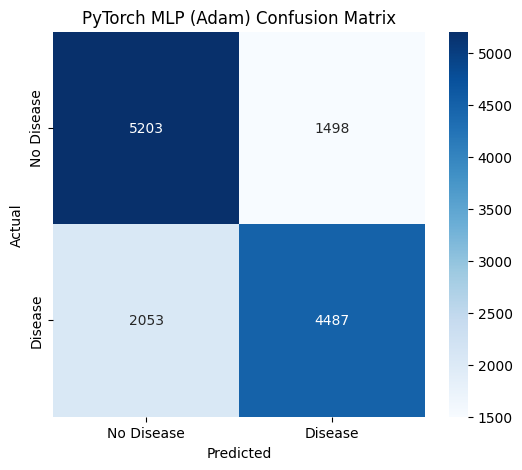

In [21]:
# Compute and visualize the confusion matrix for the Adam-trained model
cm = confusion_matrix(y_test, adam_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PyTorch MLP (Adam) Confusion Matrix")
plt.show()


## 16. ROC Curve (Adam Model)

The ROC curve plots the True Positive Rate against the False Positive Rate at various classification thresholds. The Area Under the Curve (AUC) summarizes overall model discriminative ability (closer to 1.0 is better).

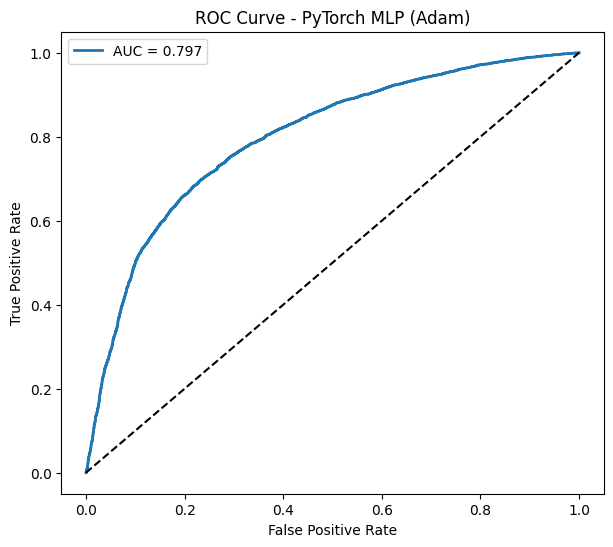

In [22]:
# Compute the ROC curve (false positive rate vs true positive rate) for the Adam model
fpr, tpr, thresholds = roc_curve(y_test, adam_probs)

plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {roc_auc_score(y_test, adam_probs):.3f}")

# Diagonal reference line representing random guessing
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PyTorch MLP (Adam)")
plt.legend()
plt.show()


## 17. Resource Consumption Analysis

Besides predictive performance, it's useful to compare the practical cost of each optimizer in terms of training time and memory usage.

In [23]:
# Track current process memory usage
process = psutil.Process(os.getpid())

resource_results = []

# Record training time and memory usage for the Adam run
resource_results.append({
    "Optimizer": "Adam",
    "Training Time (s)": adam_training_time,
    "Memory Used (MB)": process.memory_info().rss / (1024 ** 2)
})

# Record training time and memory usage for the SGD run
resource_results.append({
    "Optimizer": "SGD",
    "Training Time (s)": sgd_training_time,
    "Memory Used (MB)": process.memory_info().rss / (1024 ** 2)
})

resource_df = pd.DataFrame(resource_results)

print("=" * 70)
print("RESOURCE CONSUMPTION ANALYSIS")
print("=" * 70)
display(resource_df)


RESOURCE CONSUMPTION ANALYSIS


,Optimizer,Training Time (s),Memory Used (MB)
0,Adam,43.717314,687.121094
1,SGD,31.011228,687.121094


## 18. Save the Trained Model & Scaler

We persist the best-performing model (Adam) along with the fitted `StandardScaler`, so they can be reused later for inference without retraining.

In [24]:
# Save the Adam model's weights and the fitted scaler to disk for later reuse
torch.save(adam_model.state_dict(), "mlp_best.pt")
joblib.dump(scaler, "scaler.pkl")

print("=" * 70)
print("Best model saved successfully as 'mlp_best.pt'")
print("Scaler saved successfully as 'scaler.pkl'")
print("=" * 70)


Best model saved successfully as 'mlp_best.pt'
Scaler saved successfully as 'scaler.pkl'


## 19. Model Explainability with SHAP

To understand *why* the model makes a given prediction, we use **SHAP (SHapley Additive exPlanations)**. `KernelExplainer` is a model-agnostic method that estimates each feature's contribution by comparing predictions against a background reference sample.

In [25]:
# Put the model in evaluation mode before generating explanations
adam_model.eval()

# Background sample (SHAP needs a reference distribution)
background_idx = np.random.choice(X_train_scaled.shape[0], 100, replace=False)
background = X_train_scaled[background_idx]

def model_predict(x):
    # Wrapper so SHAP can call the PyTorch model like a plain function returning probabilities
    x_t = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        return torch.sigmoid(adam_model(x_t)).numpy()

# Create the SHAP KernelExplainer using the wrapped prediction function and background sample
explainer = shap.KernelExplainer(model_predict, background)

print("=" * 70)
print("SHAP EXPLAINER READY")
print("=" * 70)


SHAP EXPLAINER READY


## 20. SHAP Waterfall Plot for a Sample Patient

We compute SHAP values for a single test-set patient and visualize them as a waterfall plot, showing which features pushed the predicted risk higher or lower relative to the baseline (expected) prediction.

  0%|          | 0/1 [00:00<?, ?it/s]

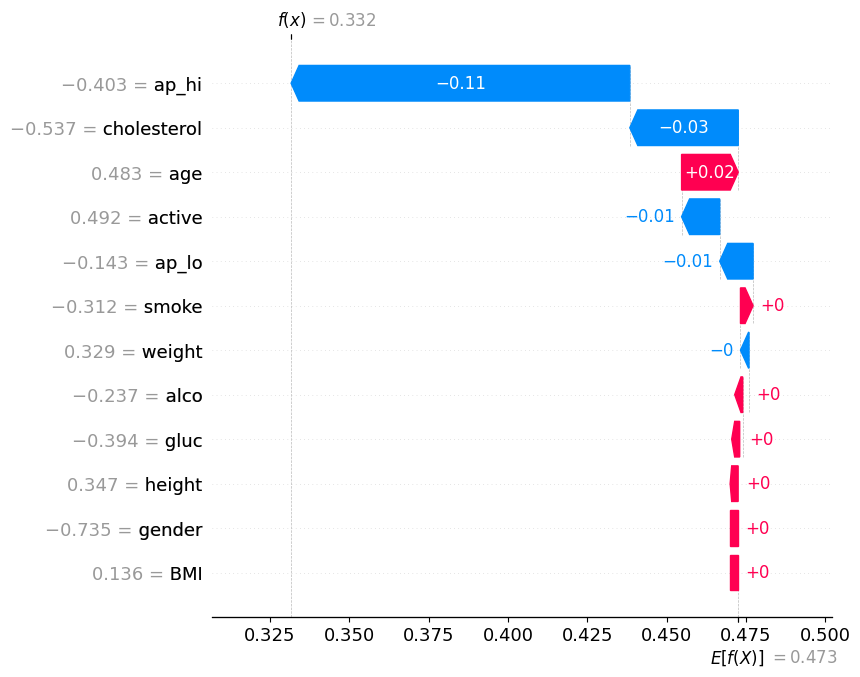

In [26]:
feature_names = X.columns.tolist()

# Pick the first patient from the scaled test set as an example
sample_patient_scaled = X_test_scaled[0]

# Compute SHAP values (feature contributions) for this patient
shap_values = explainer.shap_values(sample_patient_scaled.reshape(1, -1))

# Wrap the results in a SHAP Explanation object for easy plotting
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=sample_patient_scaled,
    feature_names=feature_names
)

# Waterfall plot: shows how each feature shifts the prediction from the baseline
shap.plots.waterfall(explanation, max_display=len(feature_names))


## 21. Risk Prediction Demo — Patient 1

As a practical demonstration, we run the trained model on a hypothetical patient's health data and visualize their predicted CVD risk as a simple progress bar (green = low risk, orange = moderate risk, red = high risk).

PATIENT 1 - RISK PREDICTION
Predicted CVD Risk : 84.39%


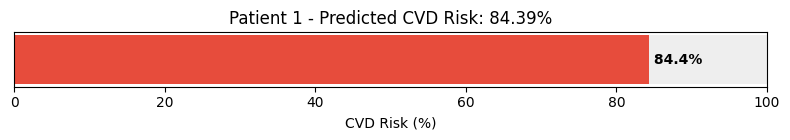

In [27]:
# Define a hypothetical patient's health measurements
patient = pd.DataFrame({
    "age": [34],
    "gender": [1],
    "height": [170],
    "weight": [75],
    "ap_hi": [140],
    "ap_lo": [90],
    "cholesterol": [3],
    "gluc": [1],
    "smoke": [1],
    "alco": [0],
    "active": [1]
})

# Calculate BMI
patient["BMI"] = patient["weight"] / ((patient["height"] / 100) ** 2)

# Scale the patient's features using the same scaler fitted on training data
patient_scaled = scaler.transform(patient[feature_names])
patient_t = torch.tensor(patient_scaled, dtype=torch.float32)

# Run inference to get the predicted risk probability
adam_model.eval()
with torch.no_grad():
    risk_score = torch.sigmoid(adam_model(patient_t)).item()

risk_pct = risk_score * 100

print("=" * 70)
print("PATIENT 1 - RISK PREDICTION")
print("=" * 70)
print(f"Predicted CVD Risk : {risk_score*100:.2f}%")


# Visualize the risk as a simple horizontal progress bar
fig, ax = plt.subplots(figsize=(8, 1.5))

# Color-code the bar based on risk level: green (low), orange (moderate), red (high)
bar_color = "#2ecc71" if risk_pct < 30 else "#f39c12" if risk_pct < 60 else "#e74c3c"

ax.barh([0], [100], color="#eeeeee", height=0.5)   # background track
ax.barh([0], [risk_pct], color=bar_color, height=0.5)  # filled portion representing risk

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("CVD Risk (%)")
ax.set_title(f"Patient 1 - Predicted CVD Risk: {risk_pct:.2f}%")

ax.text(risk_pct, 0, f" {risk_pct:.1f}%", va="center",
        ha="left" if risk_pct < 90 else "right", fontweight="bold")

plt.tight_layout()
plt.show()


## 22. Risk Prediction Demo — Patient 2

A second example patient with different (higher-risk) health indicators, to show how the predicted risk score changes accordingly.

PATIENT 2 - RISK PREDICTION
Predicted CVD Risk : 84.54%


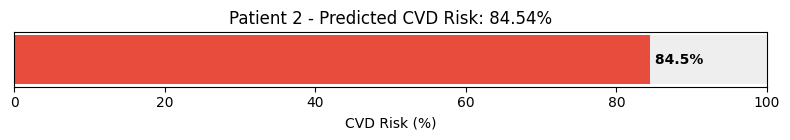

In [28]:
# Define a second hypothetical patient with higher-risk indicators
patient = pd.DataFrame({
    "age": [55],
    "gender": [2],
    "height": [160],
    "weight": [90],
    "ap_hi": [160],
    "ap_lo": [100],
    "cholesterol": [3],
    "gluc": [2],
    "smoke": [1],
    "alco": [1],
    "active": [0]
})

# Calculate BMI
patient["BMI"] = patient["weight"] / ((patient["height"] / 100) ** 2)

# Scale the patient's features using the same fitted scaler
patient_scaled = scaler.transform(patient[feature_names])
patient_t = torch.tensor(patient_scaled, dtype=torch.float32)

# Run inference to get the predicted risk probability
adam_model.eval()
with torch.no_grad():
    risk_score = torch.sigmoid(adam_model(patient_t)).item()

risk_pct = risk_score * 100


print("=" * 70)
print("PATIENT 2 - RISK PREDICTION")
print("=" * 70)
print(f"Predicted CVD Risk : {risk_score*100:.2f}%")

# Visualize the risk as a simple horizontal progress bar
fig, ax = plt.subplots(figsize=(8, 1.5))

bar_color = "#2ecc71" if risk_pct < 30 else "#f39c12" if risk_pct < 60 else "#e74c3c"

ax.barh([0], [100], color="#eeeeee", height=0.5)
ax.barh([0], [risk_pct], color=bar_color, height=0.5)

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("CVD Risk (%)")
ax.set_title(f"Patient 2 - Predicted CVD Risk: {risk_pct:.2f}%")

ax.text(risk_pct, 0, f" {risk_pct:.1f}%", va="center",
        ha="left" if risk_pct < 90 else "right", fontweight="bold")

plt.tight_layout()
plt.show()
